## Teledyne FLIR Boson+
This notebook utilizes and expands on the functions and equations given by the "PythonSimulation.ipynb" notebook to determine the validity of the Teledyne FLIR Boson+ Bolometer for the SeeSat e.V. ERWIN mission.

## Atmospheric Transmission / MODTRAN simulation
Using MODTRAN, the atmospheric transmission for a range of wavelengths can be determined

In [1223]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, k, pi
import pandas as pd

# -----------------------------------------------------------------------------
# MODTRAN CSV loader
# -----------------------------------------------------------------------------
def get_modtran_data(file_path):
    """
    Load MODTRAN output from a CSV file containing atmospheric transmission.

    Returns:
        wavelength : wavelengths [m]
        tau        : atmospheric transmission
        df         : processed dataframe
    """
    df = pd.read_csv(file_path, header=4)
    df.set_index('Freq', inplace=True)

    # remove first and last row (MODTRAN formatting artifacts)
    df = df.iloc[1:-1]

    # convert frequency index → wavelength [m] using λ = c / ν, but here file uses cm⁻¹
    df.index = 1e-2 / df.index.astype(float)
    df.index.name = 'Wavelength [m]'
    df.columns = df.columns.str.strip()

    df['combin'] = pd.to_numeric(df['combin'], errors='coerce')
    tau = df['combin'].values
    wavelength = df.index.values

    # sort in ascending wavelength
    s = np.argsort(wavelength)
    return wavelength[s], tau[s], df

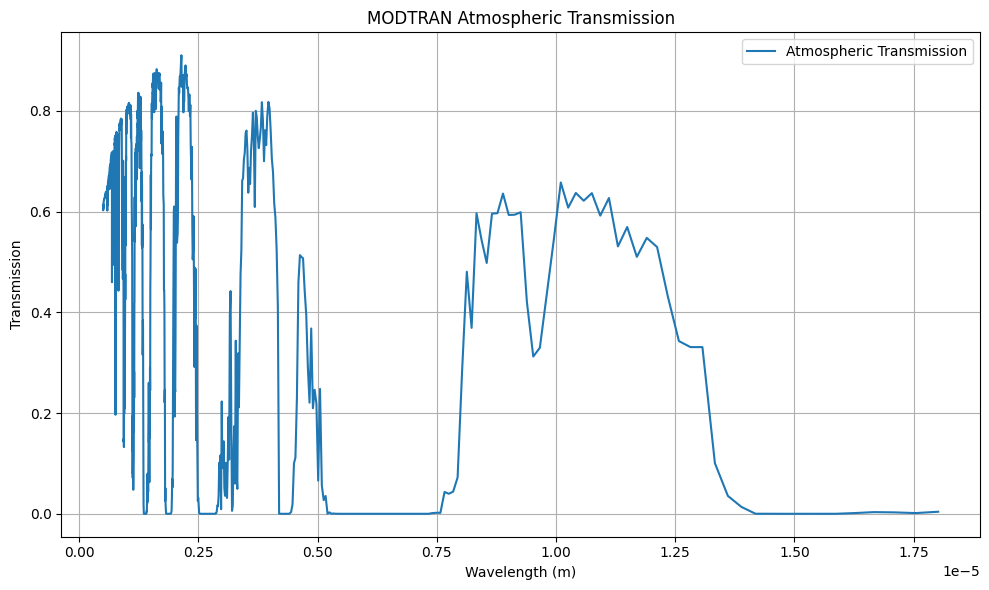

In [1224]:
# -----------------------------------------------------------------------------
# Plot MODTRAN transmittance
# -----------------------------------------------------------------------------
wavelength, transmittance, _ = get_modtran_data('./AngstromLaw2.csv')

plt.figure(figsize=(10, 6))
plt.plot(wavelength, transmittance, label='Atmospheric Transmission')
plt.xlabel('Wavelength (m)')
plt.ylabel('Transmission')
plt.title('MODTRAN Atmospheric Transmission')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Imager Specification
**Teledyne FLIR Boson+**
| Param                | Value         | Description                       |
|----------------------|------------------------|------------------------------------|
| **Wavelength-Range** | 8–14 µm                | LWIR-Spectral-Range               |
| **NETD**             | 40 mK, 50 mK, 60 mK     | Detector-Noise, depends on the imager variant|
| **Optical Transmission (1 Lens)** | τ<sub>opt</sub> = 0.87 | Transmission of one Lens             |
| **Pixel Pitch** | 12um | Pixel Pitch of the Detector |

**Mission Environment (Different Optic)**
| Param                | Value         | Description                       |
|----------------------|------------------------|------------------------------------|
| **GSD**       | 197m | Ground Sampling Distance for a single Pixel|
| **Distance**       | 600km | Common orbit for CubeSats|
| **Optical Transmission**       | 0.5 | estimation for a 5 lens design |
| **Aperture Diameter**       | 0.06m | estimation |
| **Detector Efficiency**       | 0.8 | estimation |

**Simulation Parameters**
| Param                | Value         | Description                       |
|----------------------|------------------------|------------------------------------|
| **Normal soil Temperature**       | 300K | standard Industry estimation |
| **Fire Temperature**       | 1000K | standard Industry estimation |
| **Sun Temperature**       | 1000K | standard Industry estimation |
| **$\rho_{albedo}$** | 3% | Emissivity of Ground (sun diffraction / Albedo) |
| **$\delta_{glint}$** | 1% | Area of Water on the ground (Glint) |
| **$n_{wat}$** | 1.0003 | refractive index of water |
| **$n_{air}$** | 1.35 | refractive index of air |
| **$r_{sun}$** | 695700000m | radius sun |
| **$d_{sun-earth}$** | 149597870700m | Distance sun-earth |



In [1225]:
# -----------------------------------------------------------------------------
# Sensor & scene parameters
# -----------------------------------------------------------------------------
tau_op = 0.5        # Optical transmission (5 lenses)
alpha_det = 0.8     # Detector efficiency

T_fire = 1000       # Fire temperature [K]
T_ground = 300      # Ground temperature [K]
T_sun = 5777.0      # Sun surface temperature [K]

gsd = 197           # Ground sampling distance [m]

netd_values = [0.04, 0.05, 0.06]     # NETD values

D = 0.06            # Aperture diameter [m]
d = 600e3           # Orbit altitude [m]

rho_albedo = 0.03   # Ground Emissivity
delta_glint = 0.01  # Area of Ground covered by water

# Restrict MODTRAN band (8–14 µm)
wavelength_min = 8e-6   # minimal detectable wavelength
wavelength_max = 14e-6  # maximum detectable wavelength

condition = (wavelength >= wavelength_min) & (wavelength <= wavelength_max)
band_edges = wavelength[condition]
tau_atm = transmittance[condition]

# temporaries - used for following calculations
ref_wat = 1.0003    
ref_air = 1.35

r_sun = 695700000           # Radius Sun [m]
d_sun_earth = 149597870700  # Distance Sun-Earth [m] 

pixel_pitch = 12 *1e-6

# calculated constants
# See following chapters for equations
theta_ap = 0.5 * D / d  # Aperture half-angle [rad]

area = gsd**2           # Pixel surface area [m²]

rho_wat = ((ref_air - ref_wat) / (ref_air + ref_wat))**2    # glint Factor

geom = r_sun**2 / d_sun_earth**2    # Albedo geometric conversion factor

Fno = np.ceil(pixel_pitch*d/D/gsd)  # F# number (rounded up)

# simulation Grid
temperatures = np.linspace(200, 500, 200)
delta_fire = np.linspace(0, 0.0025, 200)
delta_area = area * delta_fire

## Spectral Radiance / Planck's Law
$$ S(\lambda, T) = \frac{2 h c^2}{\lambda^5} \cdot \frac{1}{\exp\left(\tfrac{h c}{\lambda k T}\right) - 1} $$

- $S(\lambda, T)$: Spectral Radiance
- $h$: Planck constant,
- $c$: speed of light,
- $k$: Boltzmann constant,
- $T$: temperature (K),
- $\lambda$: wavelength (m)

In [1226]:
# -----------------------------------------------------------------------------
# Planck spectral radiance (per wavelength)
# B_λ(T) = 2hc² / λ⁵ · 1 / (exp(hc / (λkT)) − 1)
# Returns spectral radiance in W / (m³ sr)
# -----------------------------------------------------------------------------
def planck_lambda(lmbd, T):
    """
    Compute Planck spectral radiance as a function of wavelength.

    Parameters:
        lmbd : wavelength [m]
        T    : temperature [K]

    Returns:
        Spectral radiance [W / (m^3 sr)]
    """
    return (2 * h * c**2 / lmbd**5) / (np.exp((h * c) / (lmbd * k * T)) - 1)

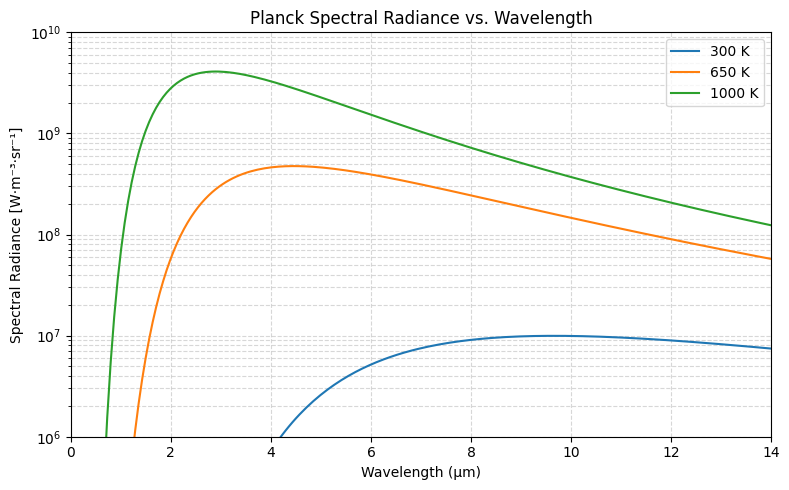

In [1227]:
# -----------------------------------------------------------------------------
# Plot: Planck radiance curves for different temperatures
# -----------------------------------------------------------------------------
wavelength_um = np.linspace(0.1, wavelength_max * 1e6, 200)
wavelength_m = wavelength_um * 1e-6

plot_temperatures = [300, 650, 1000]
labels = ["300 K", "650 K", "1000 K"]

plt.figure(figsize=(8, 5))
for T, label in zip(plot_temperatures, labels):
    radiance = planck_lambda(wavelength_m, T)
    plt.plot(wavelength_um, radiance, label=label)

plt.xlabel("Wavelength (µm)")
plt.ylabel(r"Spectral Radiance [W·m⁻³·sr⁻¹]")
plt.title("Planck Spectral Radiance vs. Wavelength")
plt.yscale('log')
plt.ylim(1e6, 1e10)
plt.xlim(0, wavelength_max * 1e6)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Power Formula
Assuming Lambertian Emission and the detector being at nadir:
$$
P_\mathrm{ow} = A_\mathrm{surface}  \cdot \left[ \sum_{n=1}^{N} \tau_n \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]\cdot \pi \sin^2(\theta_\mathrm{ap}) \cdot a
$$

$$
P_\mathrm{tw} = A_\mathrm{surface}  \cdot \left[ \sum_{n=1}^{N} \tau_n^2 \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]\cdot \pi \sin^2(\theta_\mathrm{ap})
$$

In [1228]:
# -----------------------------------------------------------------------------
# Integrate Planck radiance across a band
# -----------------------------------------------------------------------------
def integrate_band(T, l0, l1, n_samples=200):
    wavelengths = np.linspace(l0, l1, n_samples)
    spectral = planck_lambda(wavelengths, T)
    return np.trapezoid(spectral, wavelengths)

# -----------------------------------------------------------------------------
# Generic band power computation
# -----------------------------------------------------------------------------
def generic_band_power(band_edges, tau_band, area, spectral_func, spectral_args,
                       factor, theta_ap, single_transmission, n_samples=400):
    """
    Compute band‑integrated pixel power.

    Returns:
        powers_per_band : array of band powers [W]
        total_power     : sum of all bands [W]
    """
    powers = []
    for i in range(len(band_edges)-1):
        l0, l1 = band_edges[i], band_edges[i+1]
        wavelengths = np.linspace(l0, l1, n_samples)
        spectral = spectral_func(wavelengths, *spectral_args)
        I_band = np.trapezoid(spectral, wavelengths)

        if single_transmission:
            I_band_atm = I_band * tau_band[i]
        else:
            I_band_atm = I_band * tau_band[i]**2

        solid_angle = pi * (np.sin(theta_ap))**2
        P_band = factor * area * I_band_atm * solid_angle
        powers.append(P_band)

    powers = np.array(powers)
    return powers, powers.sum()

## Band Power for Ground Emission

**Ground Emission:**
$$
P_\mathrm{surface} = A_\mathrm{px} \cdot \tau_\mathrm{opt} \cdot \alpha_\mathrm{det} \cdot \epsilon_{ground} \cdot \left[ \sum_{n=1}^{N} \tau_n \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]\cdot \pi \sin^2(\theta_\mathrm{ap}) 
$$

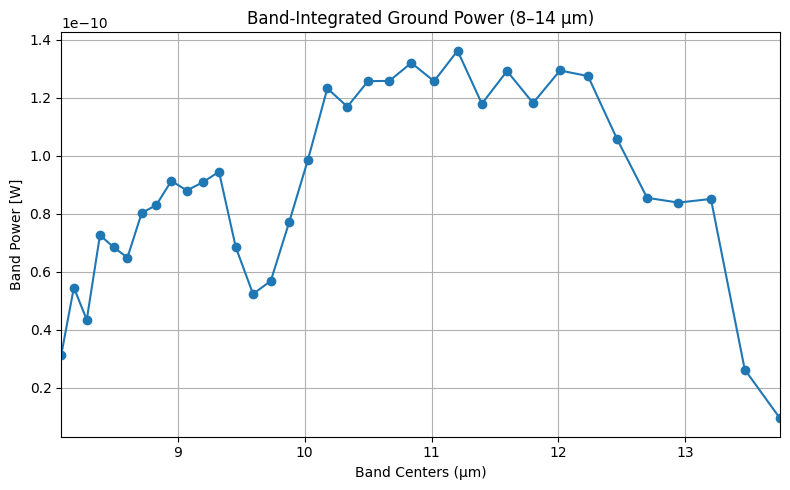

In [1229]:
# -----------------------------------------------------------------------------
# Band power for ground emission
# -----------------------------------------------------------------------------
ground_powers, _ = generic_band_power(
    band_edges, tau_atm, area,
    spectral_func=planck_lambda, spectral_args=(T_ground,),
    factor=tau_op * alpha_det, theta_ap=theta_ap,
    single_transmission=True
)

band_centers = 0.5 * (band_edges[:-1] + band_edges[1:])

plt.figure(figsize=(8, 5))
plt.plot(band_centers * 1e6, ground_powers, marker='o', label="Ground Band Power")
plt.xlim(min(band_centers* 1e6), max(band_centers* 1e6))
plt.xlabel("Band Centers (µm)")
plt.ylabel("Band Power [W]")
plt.title("Band‑Integrated Ground Power (8–14 µm)")
plt.grid(True)
plt.tight_layout()
plt.show()

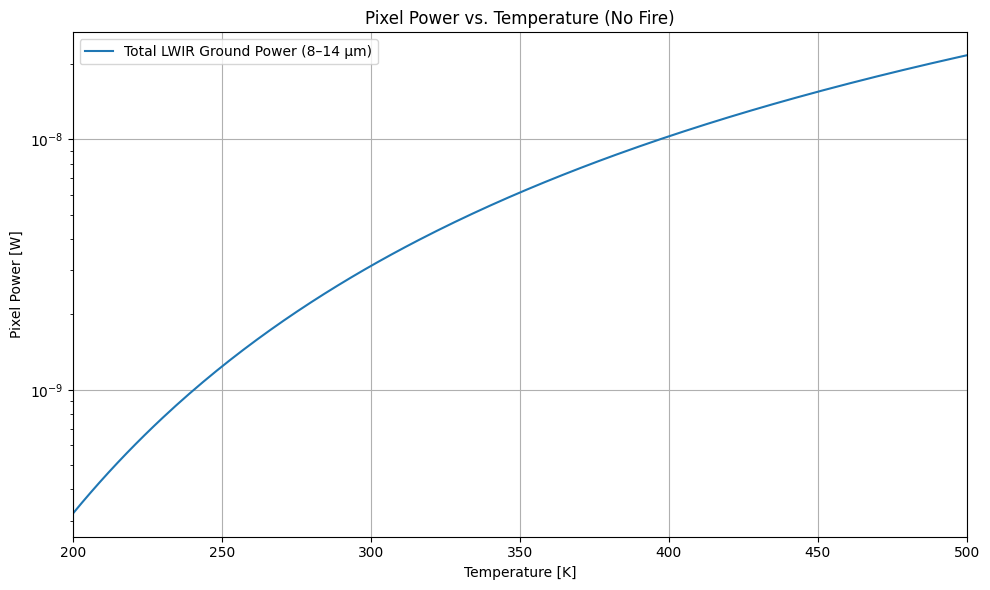

In [1230]:
# -----------------------------------------------------------------------------
# Pixel power vs. ground temperature
# -----------------------------------------------------------------------------
total_powers = []
for T in temperatures:
    _, total_power = generic_band_power(
        band_edges, tau_atm, area,
        spectral_func=planck_lambda, spectral_args=(T,),
        factor=tau_op * alpha_det, theta_ap=theta_ap,
        single_transmission=True
    )
    total_powers.append(total_power)

plt.figure(figsize=(10, 6))
plt.plot(temperatures, total_powers, label='Total LWIR Ground Power (8–14 µm)')
plt.yscale('log')
plt.xlim(min(temperatures), max(temperatures))
plt.xlabel('Temperature [K]')
plt.ylabel('Pixel Power [W]')
plt.title('Pixel Power vs. Temperature (No Fire)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## NETD / NEP

NETD and NEP are linked via the chain **scene -> radiance -> optic -> detector**

$$
\text{NEP} \;\approx\; 
\underbrace{\frac{\mathrm d P_\text{det}}{\mathrm d T}}_{\text{[W/K] at the operating point }T_0}
\cdot \text{NETD}
$$

$$
\frac{\mathrm d P_\text{px}}{\mathrm d T} \;=\;
A_\text{det}\;\tau_\text{opt}\;\pi\;\sin(\theta_{ap})\;\frac{\pi}{4\,F\#^2}
\int_{\lambda_1}^{\lambda_2} 
\underbrace{\frac{\partial S(\lambda,T)}{\partial T}}_{\text{Planck-derivate}}
\;\underbrace{\tau_\text{atm}(\lambda)}_{\text{one-way}}
\;\mathrm d\lambda
$$

- $S(\lambda,T)$: Planck-Radiance  
- $\tau_\text{atm}(\lambda)$: atmospheric transmission  
- $\tau_\text{opt}$: optical transmission
- $F\#$: f-number  
- $\theta_{ap}$: Aperture half-angle
- $A_\text{px}$: pixel area on the ground  

$$
f/\# = \frac{l \cdot d}{D \cdot a}
$$
- $l$: Bolometer Pixel-Pitch
- $d$: distance to object  
- $D$: Aperture size
- $a$: ground resolution / GSD  

The derivative of Planck's law $S(\lambda, T)$ with respect to the temperature $T$ yields:

$$
\frac{\partial S(\lambda, T)}{\partial T} =
\frac{2 h c^2}{\lambda^5} \cdot
\frac{\exp\left(\frac{h c}{\lambda k T}\right) \cdot \frac{h c}{\lambda k T^2}}
{\left[\exp\left(\frac{h c}{\lambda k T}\right) - 1\right]^2}
$$

In [1231]:
# -----------------------------------------------------------------------------
# Derivative of Planck radiance wrt temperature
# -----------------------------------------------------------------------------
def dplanck_dT(lmbd, T):
    x = (h * c) / (lmbd * k * T)
    expx = np.exp(x)
    dx_dT = -(h * c) / (lmbd * k * T**2)
    pref = 2 * h * c**2 / lmbd**5
    return pref * (-(expx * dx_dT) / (expx - 1)**2)

# -----------------------------------------------------------------------------
# dP/dT and NEP conversion
# -----------------------------------------------------------------------------
def dPdet_dT(T0, lambdas, tau_atm_lambda, area, F_number, tau_opt, theta_ap):
    factor = pi / (4 * F_number**2) * tau_opt
    powers, total = generic_band_power(
        lambdas, tau_atm_lambda, area,
        spectral_func=dplanck_dT, spectral_args=(T0,),
        factor=factor, theta_ap=theta_ap,
        single_transmission=True
    )
    return powers, total


def netd_to_nep(NETD, T0, lambdas, tau_atm_lambda, area, F_number, tau_opt, theta_ap):
    _, dP_dT = dPdet_dT(T0, lambdas, tau_atm_lambda, area, F_number, tau_opt, theta_ap)
    NEP = NETD * dP_dT
    return NEP, dP_dT

In [1232]:
# -----------------------------------------------------------------------------
# Compute NEP for each NETD
# -----------------------------------------------------------------------------
nep_results = {}
for netd in netd_values:
    nep = []
    for T in temperatures:
        nep_single, _ = netd_to_nep(netd, T, band_edges, tau_atm, area, Fno, tau_op, theta_ap)
        nep.append(nep_single)
    nep_results[netd] = nep

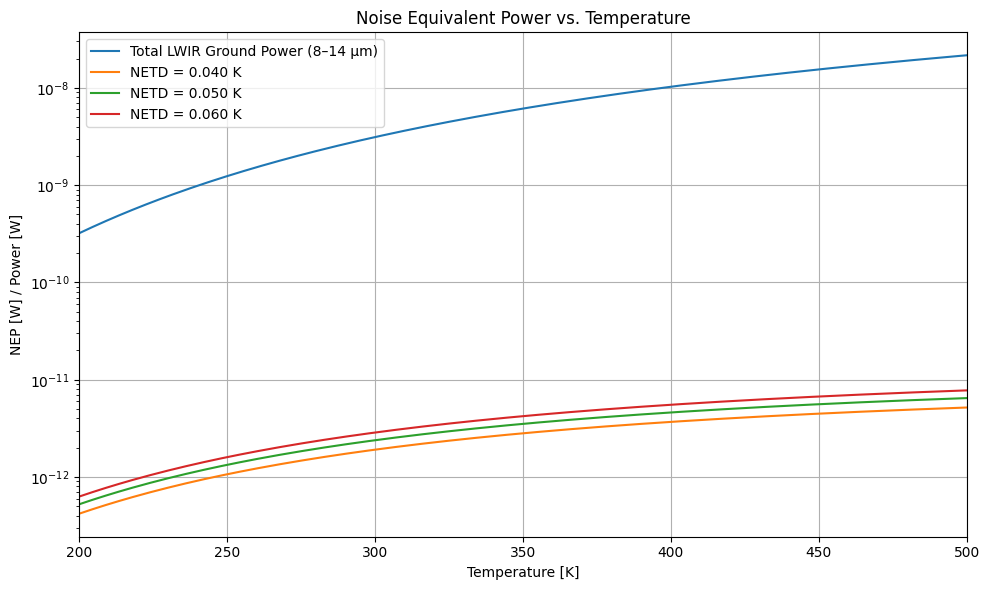

In [1233]:
# -----------------------------------------------------------------------------
# Plot NEP curves
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(temperatures, total_powers, label='Total LWIR Ground Power (8–14 µm)')

for netd, nep in nep_results.items():
    plt.plot(temperatures, nep, label=f'NETD = {netd:.3f} K')

plt.yscale('log')
plt.xlabel('Temperature [K]')
plt.ylabel('NEP [W] / Power [W]')
plt.xlim(min(temperatures), max(temperatures))
plt.title('Noise Equivalent Power vs. Temperature')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Mixed Pixels:
$$P_{mix,Band} = (1 - \delta_{fire}) \cdot P_{ground,Band} + \delta_{fire} \cdot P_{fire,Band} $$

In [1234]:
# -----------------------------------------------------------------------------
# Mixed pixel model (ground + fire)
# -----------------------------------------------------------------------------
def mixed_pixel_power_ground_fire(T_ground, T_fire, delta_fire, band_edges, tau_band,
                                  area, tau_opt, alpha_det, theta_ap):
    """
    Compute pixel power for a mixture of ground and fire emission.

    delta_fire : fractional fire coverage [0..1]
    Returns: (band powers, total power)
    """
    factor = tau_opt * alpha_det

    P_ground_band, _ = generic_band_power(
        band_edges, tau_band, area, planck_lambda, (T_ground,),
        factor=factor, theta_ap=theta_ap, single_transmission=True)

    P_fire_band, _ = generic_band_power(
        band_edges, tau_band, area, planck_lambda, (T_fire,),
        factor=factor, theta_ap=theta_ap, single_transmission=True)

    P_mix_band = (1 - delta_fire) * P_ground_band + delta_fire * P_fire_band
    return P_mix_band, P_mix_band.sum()

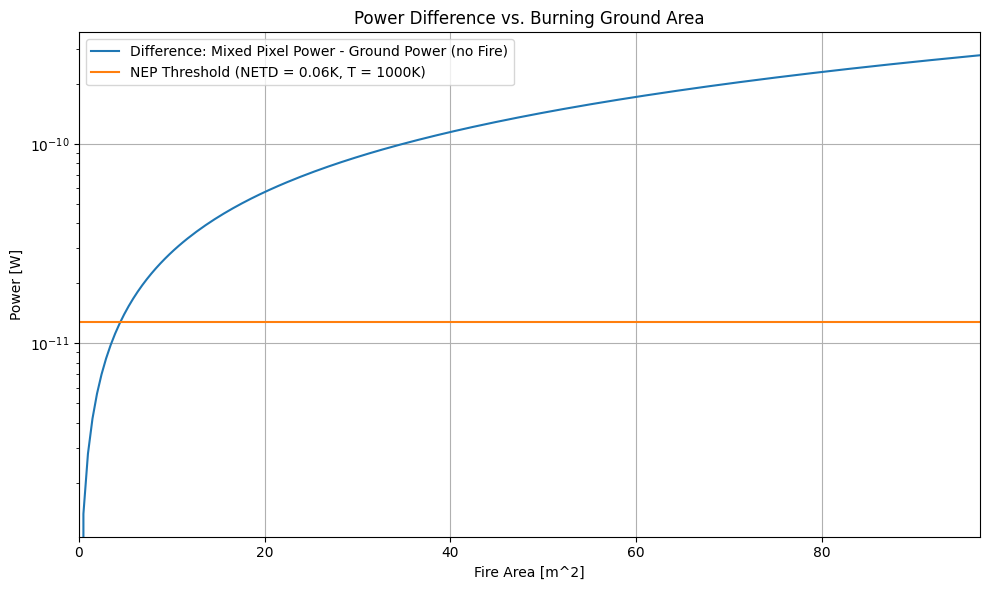

min detectable fire area = 4.875502512562814
min detectable delta_fire = 0.01256281407035176%
! Result is only in terms of NEP !
! Does not take parasitic detections into account !


In [1235]:
# -----------------------------------------------------------------------------
# Mixed pixel power difference vs. fire coverage
# -----------------------------------------------------------------------------
# Boden-Emission
P_ground_band, P_ground_total = generic_band_power(
    band_edges, tau_atm, area, theta_ap=theta_ap,
    spectral_func=planck_lambda, spectral_args=(T_ground,),
    factor=alpha_det * tau_op,
    single_transmission=True  # Use single transmission value for ground emission
)


mix_powers = []
power_differences = []
for delta_cur in delta_fire:
    _, Pmix = mixed_pixel_power_ground_fire(T_ground, T_fire, delta_cur,
                                           band_edges, tau_atm, area,
                                           tau_op, alpha_det, theta_ap)
    power_differences.append(Pmix - P_ground_total)
    mix_powers.append(Pmix)

nep_fire, _ = netd_to_nep(max(netd_values), T_fire, band_edges, tau_atm, area, Fno, tau_op, theta_ap)
nep_fire_array = [nep_fire] * len(delta_fire)

plt.figure(figsize=(10,6))
plt.plot(delta_area, power_differences, label="Difference: Mixed Pixel Power - Ground Power (no Fire)")
plt.plot(delta_area, nep_fire_array, label=f"NEP Threshold (NETD = {max(netd_values)}K, T = {T_fire}K)")
plt.yscale("log")
plt.xlim(min(delta_area), max(delta_area))
plt.xlabel('Fire Area [m^2]')
plt.ylabel('Power [W]')
plt.title('Power Difference vs. Burning Ground Area')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"min detectable fire area = {min(delta_area[power_differences > nep_fire])}")
print(f"min detectable delta_fire = {min(delta_fire[power_differences > nep_fire])*100}%")
print("! Result is only in terms of NEP !\n\r! Does not take parasitic detections into account !")

## Total Pixel Power

**Ground Emission**
$$
P_\mathrm{surface} = A_\mathrm{px} \cdot \tau_\mathrm{opt} \cdot \alpha_\mathrm{det} \cdot \epsilon_{ground} \cdot \left[ \sum_{n=1}^{N} \tau_n \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \right]\cdot \pi \sin^2(\theta_\mathrm{ap}) 
$$

**Albedo**
$$P_\mathrm{albedo} = A_\mathrm{px} \cdot \tau_\mathrm{opt} \cdot \alpha_\mathrm{det} \cdot G \cdot \rho_{alb} \cdot \left[ \sum_{n=1}^{N} \tau_n^2 \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T_{sun})\, d\lambda  \right] \cdot \pi \sin^2(\theta_\mathrm{ap})$$

$$G=\frac{r_{sun}^2}{d_{sun - earth}^2}$$


**Glint**
$$P_\mathrm{Band,\,total,\,tw} = A_\mathrm{px} \cdot \tau_\mathrm{opt} \cdot \alpha_\mathrm{det} \cdot \delta_{glint} \cdot \rho_{wat} \cdot \left[ \sum_{n=1}^{N} \tau_n^2 \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T_{sun})\, d\lambda  \right] \cdot \pi \sin^2(\theta_\mathrm{ap})$$

$$\rho_{wat} = (\frac{m_1 - m_2}{m_1 + m_2})^2$$

In [1236]:
detector_factor = tau_op * alpha_det

# Albedo (reflektierte Solarleistung)
P_albedo_band, P_albedo_total = generic_band_power(
    band_edges, tau_atm, area, theta_ap=theta_ap,
    spectral_func=planck_lambda, spectral_args=(T_sun,),
    factor=rho_albedo * geom * detector_factor,
    single_transmission=False
)

# Glint (vereinfachte Annahme: wie Albedo, aber mit delta_glint als Faktor)
P_glint_band, P_glint_total = generic_band_power(
    band_edges, tau_atm, area, theta_ap=theta_ap,
    spectral_func=planck_lambda, spectral_args=(T_sun,),
    factor=delta_glint * rho_wat * detector_factor,
    single_transmission=False
)

# Gesamtsumme
P_total_band = P_ground_band + P_albedo_band + P_glint_band
P_total = P_total_band.sum()


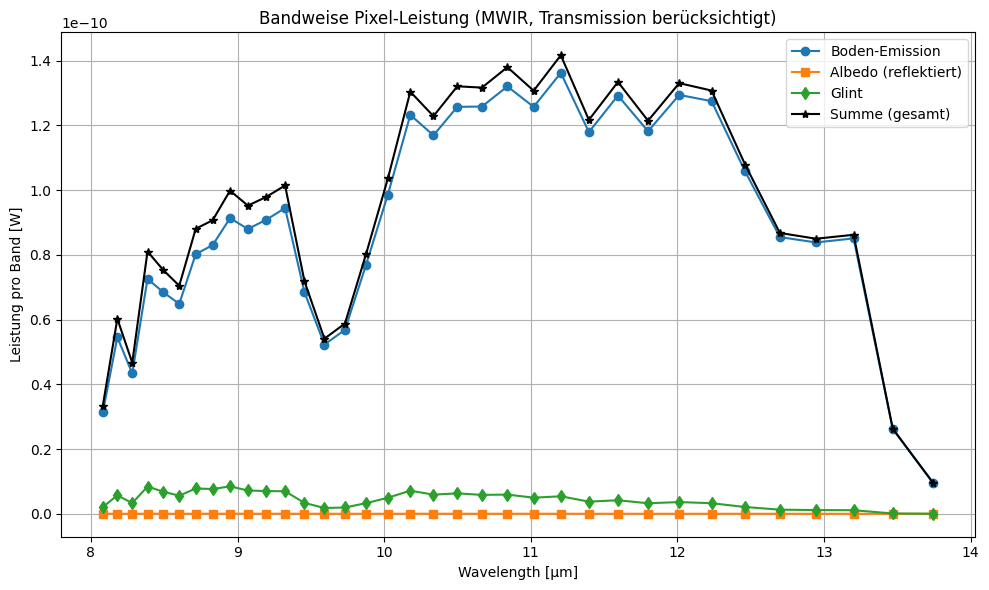

In [1237]:
plt.figure(figsize=(10,6))
plt.plot(band_centers * 1e6, P_ground_band, 'o-', label='Boden-Emission')
plt.plot(band_centers * 1e6, P_albedo_band, 's-', label='Albedo (reflektiert)')
plt.plot(band_centers * 1e6, P_glint_band, 'd-', label='Glint')
plt.plot(band_centers * 1e6, P_total_band, 'k*-', label='Summe (gesamt)')

plt.xlabel('Wavelength [µm]')
plt.ylabel('Leistung pro Band [W]')
#plt.yscale('log')
plt.title('Bandweise Pixel-Leistung (MWIR, Transmission berücksichtigt)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Total Transmission for mixed Pixels

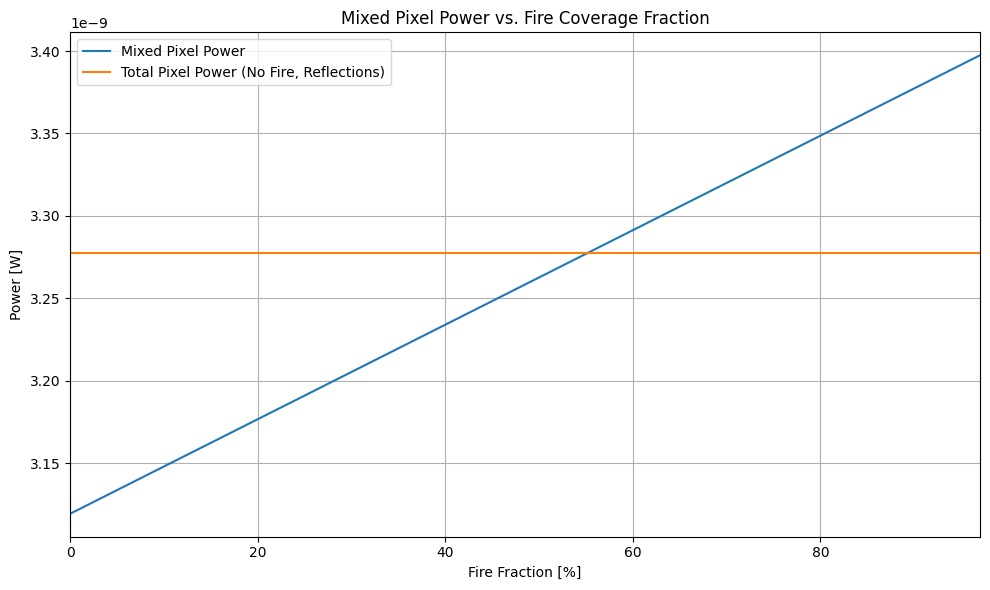

min detectable fire area = 55.580728643216084
min detectable delta_fire = 0.14321608040201006%
! Use These values !


In [1238]:
P_total_array = [P_total] * len(delta_area)

plt.figure(figsize=(10,6))
plt.plot(delta_area, mix_powers, label="Mixed Pixel Power")
plt.plot(delta_area, P_total_array, label="Total Pixel Power (No Fire, Reflections)")
#plt.yscale("log")
plt.xlim(min(delta_area), max(delta_area))
plt.xlabel('Fire Fraction [%]')
plt.ylabel('Power [W]')
plt.title('Mixed Pixel Power vs. Fire Coverage Fraction')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"min detectable fire area = {min(delta_area[mix_powers > P_total])}")
print(f"min detectable delta_fire = {min(delta_fire[mix_powers > P_total])*100}%")
print("! Use These values !")